In [1]:
# By Joe Ho (PolyU Student ID: 21010627G)

In [2]:
#Import Necessary Libraries and Package
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from pandas.plotting import register_matplotlib_converters
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential, load_model
from keras.layers import LSTM, Dense, Dropout
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
register_matplotlib_converters()




In [3]:
#define the ticker symbol and get Stock Information from Yahoo Finance
tickerSymbol = '2800.HK'

In [4]:
#get data on this ticker
stockTicketDataSet = yf.Ticker(tickerSymbol)

In [5]:
#get the historical prices for this ticker
stockdata = stockTicketDataSet.history(period='1d', start='2008-1-1', end='2022-9-29')

In [6]:
stockdata = stockdata[['Close']]

In [7]:
#Get the number of trading days:
stockdata.shape

(3637, 1)

In [8]:
#see your data
stockdata.tail()

,Close
Date,
2022-09-22,18.809999
2022-09-23,18.580000
2022-09-26,18.500000
2022-09-27,18.520000
2022-09-28,17.900000


In [9]:
stockdata.head()

,Close
Date,
2008-01-02,27.730000
2008-01-03,27.059999
2008-01-04,27.690001
2008-01-07,27.350000
2008-01-08,27.280001


Text(0, 0.5, 'Price')

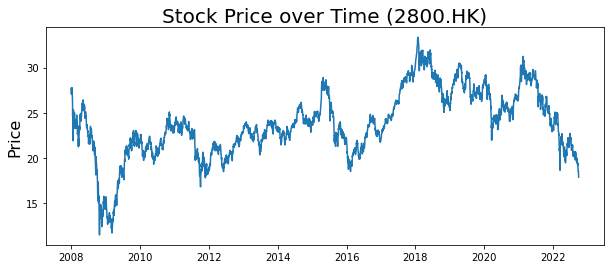

In [10]:
plt.figure(figsize=(10,4))
plt.plot(stockdata.Close)
plt.title('Stock Price over Time (%s)'%tickerSymbol, fontsize=20)
plt.ylabel('Price', fontsize=16)


In [11]:
newdf = stockdata.reset_index()

In [12]:
newdf[['ds','y']] = newdf[['Date' ,'Close']]

In [13]:
newdf = newdf[['ds','y']]

In [14]:
newdf

,ds,y
0,2008-01-02,27.730000
1,2008-01-03,27.059999
2,2008-01-04,27.690001
3,2008-01-07,27.350000
4,2008-01-08,27.280001
...,...,...
3632,2022-09-22,18.809999
3633,2022-09-23,18.580000
3634,2022-09-26,18.500000
3635,2022-09-27,18.520000


In [15]:
#Let's Clean up the Date Value and only keep the price value
newdf = newdf['y'].values


In [16]:
#Reshape the data set
newdf = newdf.reshape(-1, 1)


In [17]:
# Split The Test Data

dataset_train = np.array(newdf[:int(newdf.shape[0]*0.8)])
dataset_test = np.array(newdf[int(newdf.shape[0]*0.8):])


In [18]:
# Normalize the Data for better Prediction
# This time we use MinMaxScaler Scaler to normalize the data

scaler = MinMaxScaler(feature_range=(0,1))
dataset_train = scaler.fit_transform(dataset_train)
dataset_test = scaler.transform(dataset_test)


In [19]:
#Create a Function that will help us to create the datasets

#In this function, for the features (x), we will always append the last 50 prices, 
#and for the label (y), we will append the next price. 
#Then we will use numpy to convert it into an array.


def create_dataset(df):
    x = []
    y = []
    for i in range(50, df.shape[0]):
        x.append(df[i-50:i, 0])
        y.append(df[i, 0])
    x = np.array(x)
    y = np.array(y)
    return x,y

In [20]:
x_train, y_train = create_dataset(dataset_train)
x_test, y_test = create_dataset(dataset_test)


In [21]:
model = Sequential()
model.add(LSTM(units=96, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=96,return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(units=96,return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(units=96))
model.add(Dropout(0.2))
model.add(Dense(units=1))


In [22]:
model.compile(loss='mean_squared_error', optimizer='adam')


In [23]:
model.fit(x_train, y_train, epochs=50, batch_size=32)


Epoch 1/50
90/90 [==============================] - 20s 110ms/step - loss: 0.0150
Epoch 2/50
90/90 [==============================] - 9s 97ms/step - loss: 0.0039
Epoch 3/50
90/90 [==============================] - 8s 91ms/step - loss: 0.0033
Epoch 4/50
90/90 [==============================] - 8s 90ms/step - loss: 0.0030
Epoch 5/50
90/90 [==============================] - 9s 98ms/step - loss: 0.0030
Epoch 6/50
90/90 [==============================] - 8s 93ms/step - loss: 0.0030
Epoch 7/50
90/90 [==============================] - 9s 103ms/step - loss: 0.0024
Epoch 8/50
90/90 [==============================] - 9s 96ms/step - loss: 0.0024
Epoch 9/50
90/90 [==============================] - 9s 102ms/step - loss: 0.0023
Epoch 10/50
90/90 [==============================] - 9s 103ms/step - loss: 0.0021
Epoch 11/50
90/90 [==============================] - 9s 104ms/step - loss: 0.0021
Epoch 12/50
90/90 [==============================] - 9s 98ms/step - loss: 0.0020
Epoch 13/50
90/90 [============

In [24]:
#Save the Trained Model
model.save('stock_prediction_2800hk_joeho.h5')


In [25]:
#Load the Trained Model
model = load_model('stock_prediction_2800hk_joeho.h5')


22/22 [==============================] - 3s 34ms/step


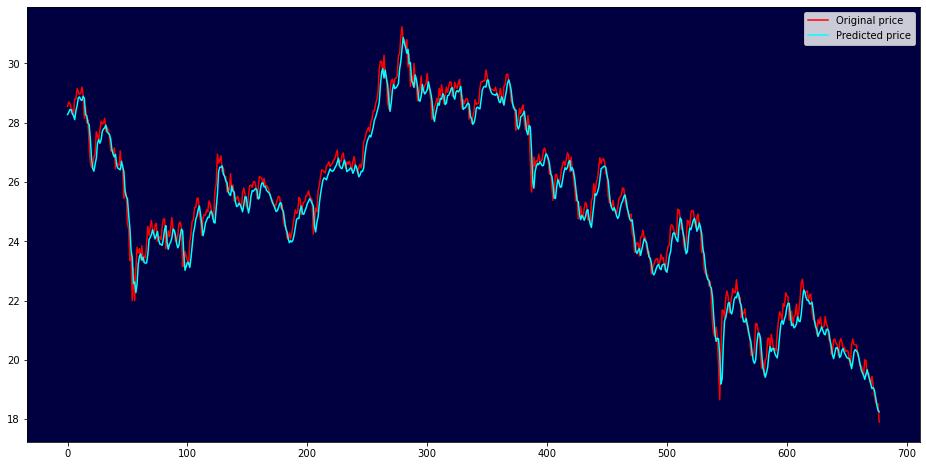

In [26]:
#Plot Prediction Result Visualization
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)
y_test_scaled = scaler.inverse_transform(y_test.reshape(-1, 1))

fig, ax = plt.subplots(figsize=(16,8))
ax.set_facecolor('#000041')
ax.plot(y_test_scaled, color='red', label='Original price')
plt.plot(predictions, color='cyan', label='Predicted price')
plt.legend()


In [28]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error


In [31]:
rmse=mean_squared_error(y_test_scaled, predictions, squared=False)
mape=mean_absolute_percentage_error(y_test_scaled,predictions)
print("RSME:",rmse)
print("MAPE:",mape)

RSME: 0.4334331438730277
MAPE: 0.013457546790553372
